In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import models

import matplotlib.pyplot as plt
import numpy as np

import time
import copy

from tqdm.auto import tqdm

In [3]:
model_type = "TRAIN"
# model_type = "LOAD"

## CONFIGURAÇÕES E HIPERPARÂMETROS

In [4]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Hiperparâmetros
BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 0.01

Usando dispositivo: cuda


## PREPARAÇÃO DE DADOS

In [5]:
stats_stl10 = ((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))

In [7]:
transform_pt_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])
transform_pt_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])

trainset_pt = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_pt_train)
loader_pt_train = torch.utils.data.DataLoader(trainset_pt, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset_pt = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_pt_test)
loader_pt_test = torch.utils.data.DataLoader(testset_pt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [8]:
def denormalize(tensor, mean, std):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        # A conta inversa da normalização: pixel * std + mean
        t.mul_(s).add_(m)
    return tensor

def show_batch(loader, stats):
    images, labels = next(iter(loader))

    # Vamos pegar apenas as primeiras 16 imagens para não poluir
    images = images[:8]
    labels = labels[:8]

    # Criar um grid de imagens
    grid_img = torchvision.utils.make_grid(images, nrow=4, padding=2)

    mean, std = stats
    grid_img = denormalize(grid_img, mean, std)

    # Converter para Numpy e Transpor (C, H, W) -> (H, W, C)
    np_img = grid_img.numpy()
    np_img = np.transpose(np_img, (1, 2, 0))

    plt.figure(figsize=(10, 10))
    plt.imshow(np_img, vmin=0, vmax=1)
    plt.axis('off')
    plt.show()

    # Mostrar as classes correspondentes
    classes = loader.dataset.classes
    print('\nClasses:', [classes[l] for l in labels])

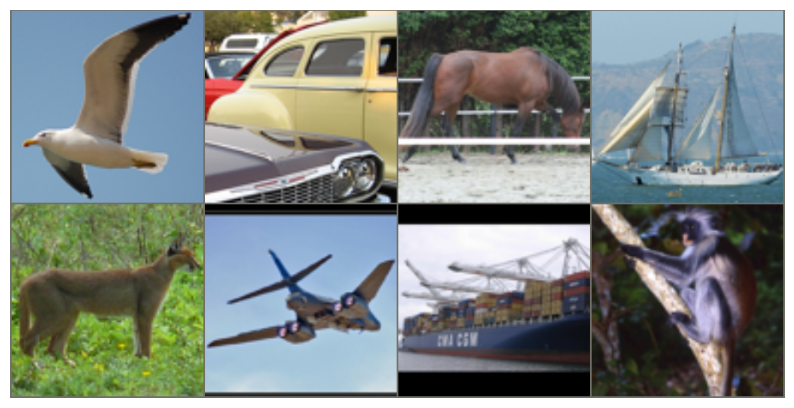


Classes: ['bird', 'car', 'horse', 'ship', 'cat', 'airplane', 'ship', 'monkey']


In [9]:
show_batch(loader_pt_train, stats_stl10)

## DEFINIÇÃO DO MODELO

In [10]:
def get_pretrained_model_optimized():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)


## TREINAMENTO

In [30]:
def train(model, loader_train, loader_test, name="Model", patience=4):
    print(f"\n--- Treinando: {name} (Patience: {patience}) ---")

    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE,
                          momentum=0.9, weight_decay=5e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    criterion = nn.CrossEntropyLoss()

    # Histórico expandido
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    # Variáveis para o Early Stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_wts = copy.deepcopy(model.state_dict()) # Guarda o estado inicial

    for epoch in range(NUM_EPOCHS):
        # --- TREINAMENTO ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(loader_train, desc=f"Ep {epoch+1}/{NUM_EPOCHS}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            loop.set_postfix(loss=loss.item())

        # Métricas de treino da época
        epoch_train_loss = running_loss / len(loader_train)
        epoch_train_acc = 100. * correct / total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # --- VALIDAÇÃO ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in loader_test:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)

                # Agora calculamos a loss de validação também
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # Métricas de validação da época
        epoch_val_loss = val_running_loss / len(loader_test)
        epoch_val_acc = 100. * val_correct / val_total

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Scheduler step
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        print(f"Ep {epoch+1}/{NUM_EPOCHS} | LR: {current_lr:.5f} | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")

        # --- EARLY STOPPING CHECK ---
        # Verifica se a loss de validação melhorou
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict()) # Salva os pesos na memória
            patience_counter = 0 # Reseta o contador
            # print(f"  -> Novo melhor modelo salvo! (Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping ativado! Parando na época {epoch+1}.")
                break

    # Ao final, carrega os melhores pesos encontrados durante o treino
    print(f"Carregando melhor modelo com Val Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_model_wts)

    return history

In [31]:
if model_type == "TRAIN":
    model_pt = get_pretrained_model_optimized()
    hist_pt = train(model_pt, loader_pt_train, loader_pt_test, name="Pre-Trained (Resize 224)")

    save_path = 'model_resnet_stl10.pth'
    torch.save(model_pt.state_dict(), save_path)

    print(f"Model saved - path: {save_path}")


--- Treinando: Pre-Trained (Resize 224) (Patience: 4) ---


Ep 1/15:   0%|          | 0/79 [00:00<?, ?it/s]

Ep 1/15 | LR: 0.00989 | Train Loss: 0.4440 Acc: 85.70% | Val Loss: 0.2967 Acc: 90.04%


Ep 2/15:   0%|          | 0/79 [00:00<?, ?it/s]

Ep 2/15 | LR: 0.00957 | Train Loss: 0.1626 Acc: 94.50% | Val Loss: 0.3074 Acc: 89.90%


...

Ep 13/15 | LR: 0.00043 | Train Loss: 0.0026 Acc: 100.00% | Val Loss: 0.1527 Acc: 95.20%


Ep 14/15:   0%|          | 0/79 [00:00<?, ?it/s]

Ep 14/15 | LR: 0.00011 | Train Loss: 0.0021 Acc: 100.00% | Val Loss: 0.1547 Acc: 95.21%


Ep 15/15:   0%|          | 0/79 [00:00<?, ?it/s]

Ep 15/15 | LR: 0.00000 | Train Loss: 0.0051 Acc: 99.98% | Val Loss: 0.1549 Acc: 95.19%
Carregando melhor modelo com Val Loss: 0.1527
Model saved - path: model_resnet_stl10.pth


## MÉTRICAS

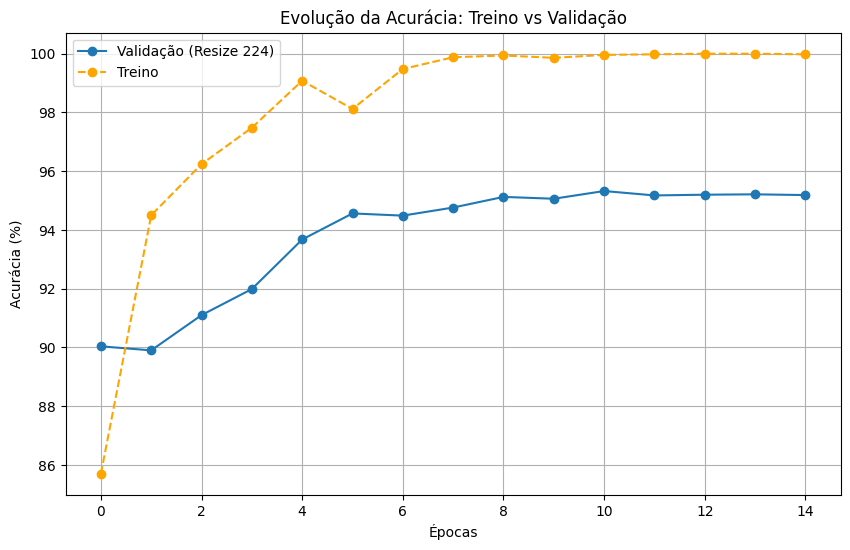

In [33]:
plt.figure(figsize=(10, 6))

# Plot da Validação (Linha original)
plt.plot(hist_pt['val_acc'], label='Validação (Resize 224)', marker='o')

# Plot do Treino (Laranja)
plt.plot(hist_pt['train_acc'], label='Treino', color='orange', marker='o', linestyle='--')

plt.title('Evolução da Acurácia: Treino vs Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_train_val_comparison.png')
plt.show()